<br>
<font>
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=150 height=150> <br>
<font color=0F5298 size=7>
    Machine learning <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Fall 2025<br>
<font color=3C99D size=5>
    Practical Assignment 5 - NLP - Word Embeddings & Fine-Tuning <br>
</div>
<div dir=ltr align=center>
<font color=0CBCDF size=4>
     Emad Rostamian, Seyed Moein Ayyoubzadeh
<br>
<font color=0CBCDF size=4>
</div>

____

<font color=9999FF size=4>
Full Name : Amitis Mirabedini
<br>
<font color=9999FF size=4>
Student Number : 402102562

<font color=0080FF size=3>
This notebook covers two related topics in modern NLP. In the first part, we study word embedding methods, including traditional and neural approaches, to understand how semantic information is represented in vector space. In the second part, we explore fine-tuning strategies for pretrained language models, with a focus on parameter-efficient methods such as LoRA, and analyze their behavior during training.
</font>

# Section 1: Exploring Word Embeddings

## 🎯 Objective

In this section, you will **build, explore, and compare different types of word representations (embeddings)** to understand how machines capture the meaning of words from text.


---

## 📚 Dataset

We will work with the complete **_Harry Potter_ series (Books 1–7)**, loaded from a public Hugging Face dataset.

⚠️ **Note:** This text is used **only for educational purposes**.


---

## 🛠️ What You Will Do

You will:
1. **Implement from scratch**
   - TF-IDF
   - Word2Vec-style embeddings (CBOW and Skip-Gram)
   - Nearest-neighbor search (word similarity)
2. **GloVe: Global Vectors for Word Representation**
   - Exploring word vectors
   - Word Analogies

## Part 1: Implement from scratch

## 1. Traditional Word Representations: TF-IDF

Before learning dense vector embeddings, we start with a **traditional and interpretable** way of representing words: **TF-IDF**.

TF-IDF does *not* try to learn meaning from prediction tasks. Instead, it represents words based on how **frequently** they appear and how **informative** they are across documents.

---

## Term Frequency (TF)

Term Frequency measures how often a word appears in a document.

For a word $ w $ in document $ d $:

$$
\text{TF}(w, d) = \frac{\text{count of } w \text{ in } d}{\text{total number of words in } d}
$$

Intuition:
- Words that appear often in a document are likely important *for that document*

---

## Inverse Document Frequency (IDF)

Inverse Document Frequency downweights words that appear in *many* documents.

$$
\text{IDF}(w) = \log\left(\frac{1 + N}{1 + \text{DF}(w)}\right) + 1
$$

Where:
- $ N $ = total number of documents  
- $ \text{DF}(w) $ = number of documents containing word \( w \)

Why the **+1** terms:
- `+1` in the denominator prevents division by zero  
- `+1` in the numerator keeps the ratio ≥ 1  
- `+1` outside the log prevents zero IDF values  

Intuition:
- Common words get low weight  
- Rare words get high weight  
- All words keep a positive contribution  


---

## TF-IDF Score

The final TF-IDF representation combines both ideas:

$$
\text{TF-IDF}(w, d) = \text{TF}(w, d) \times \text{IDF}(w)
$$

Each document is represented as a **high-dimensional sparse vector**, where:
- Each dimension corresponds to a word in the vocabulary
- Values reflect word importance


---

## Your Task

In this section, you will:

1. Load **Harry Potter and the Sorcerer’s Stone**
2. Split the book into **chapters** (each chapter = one document)
3. Build **TF-IDF vectors from scratch**
4. Use TF-IDF to:
   - Find the most important words in a chapter
   - Compute similarity between chapters
   - Compare words based on their TF-IDF representations

Do **not** use `sklearn`’s `TfidfVectorizer`.

The goal is to understand *how TF-IDF works internally*.


In [4]:
# Standard library
import re
import math
import random
from collections import Counter, defaultdict

# Third-party libraries
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Hugging Face
from datasets import load_dataset

# Scikit-learn
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [5]:
# Load dataset
hp_ds = load_dataset("elricwan/HarryPotter")

# Each book is one document
books = hp_ds["train"]

# Extract book texts
documents = [book["content"] for book in books]
documents = documents[:-1]
print(f"Number of books: {len(documents)}")


README.md:   0%|          | 0.00/353 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/7.81M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8 [00:00<?, ? examples/s]

Number of books: 7


In [6]:
# TODO: Preprocessing : Normalize text and remove punctuation and stopwords
def preprocess(text):
    # 1) lowercase
    text = text.lower()

    # 2) keep only letters + spaces (removes punctuation, digits, etc.)
    #    (If you want to keep apostrophes for contractions, tell me and I’ll adjust.)
    text = re.sub(r"[^a-z\s]", " ", text)

    # 3) collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    # 4) tokenize
    tokens = text.split()

    # 5) remove stopwords + tiny tokens
    tokens = [t for t in tokens if (t not in ENGLISH_STOP_WORDS and len(t) > 2)]

    return tokens

docs = [preprocess(doc) for doc in documents]

# TODO: Print number of Tokens in each book(doc)
for i, doc in enumerate(docs):
    print(f"Book {i+1}: {len(doc):,} tokens")


Book 1: 37,597 tokens
Book 2: 43,778 tokens
Book 3: 54,107 tokens
Book 4: 93,135 tokens
Book 5: 123,557 tokens
Book 6: 80,426 tokens
Book 7: 92,649 tokens


In [8]:
# TODO: Build a shared corpus and initial vocabulary
corpus = [tok for doc in docs for tok in doc]          # flatten all docs into one big list of tokens
vocab = set(corpus)                                   # initial vocab (before pruning)

# TODO: Remove rare words below frequency threshold
min_freq = 5  # you can tune this (e.g., 2, 5, 10)
token_counts = Counter(corpus)

vocab = {w for w, c in token_counts.items() if c >= min_freq}

# (optional but recommended) add a token for unknown words
UNK = "<UNK>"
vocab.add(UNK)

# TODO: Create word ↔ index lookup tables
# (nice to sort for reproducibility)
vocab = sorted(vocab)
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

# TODO: Filter corpus to known vocabulary and convert to indices
corpus_filtered = [w if w in word2idx else UNK for w in corpus]
corpus_indices = [word2idx[w] for w in corpus_filtered]

# TODO: Print corpus size and vocabulary size
print(f"Corpus tokens (raw): {len(corpus):,}")
print(f"Corpus tokens (indexed): {len(corpus_indices):,}")
print(f"Vocabulary size (min_freq={min_freq}): {len(vocab):,}")


Corpus tokens (raw): 525,249
Corpus tokens (indexed): 525,249
Vocabulary size (min_freq=5): 8,793


In [10]:
# TODO: Compute TF
def tf(doc):
    vec = np.zeros(len(word2idx))
    
    counts = Counter(doc)
    total = len(doc)
    
    for word, count in counts.items():
        if word in word2idx:  # ignore words not in vocab
            vec[word2idx[word]] = count / total
            
    return vec

tf_docs = [tf(doc) for doc in docs]


# TODO: Compute IDF
def idf(docs):
    N = len(docs)
    df = np.zeros(len(word2idx))
    
    for doc in docs:
        unique_words = set(doc)
        for w in unique_words:
            if w in word2idx:
                df[word2idx[w]] += 1
    
    # smooth IDF to avoid div by zero
    idf_vec = np.log((N + 1) / (df + 1)) + 1
    
    return idf_vec

idf = idf(docs)


# TODO:Compute TF-IDF
def compute_tfidf(tf_vec, idf_vec):
    return tf_vec * idf_vec

tfidf_docs = [compute_tfidf(tf_vec, idf) for tf_vec in tf_docs]


In [11]:
# TODO: Extract and display top TF-IDF terms per document

def top_k_words(tfidf_doc, k=5):
    # get indices of top k scores
    top_indices = np.argsort(tfidf_doc)[-k:][::-1]
    
    # map indices to words + scores
    top_words = [(idx2word[i], tfidf_doc[i]) for i in top_indices]
    
    return top_words


for i, tfidf_doc in enumerate(tfidf_docs):
    print(f"\nDocument {i+1} top words:")
    
    top_words = top_k_words(tfidf_doc, k=5)
    
    for word, score in top_words:
        print(f"{word:15s} {score:.4f}")



Document 1 top words:
harry           0.0375
said            0.0219
ron             0.0116
hagrid          0.0099
hermione        0.0073

Document 2 top words:
harry           0.0402
said            0.0278
ron             0.0165
lockhart        0.0079
hermione        0.0075

Document 3 top words:
harry           0.0383
said            0.0279
ron             0.0146
hermione        0.0125
lupin           0.0097

Document 4 top words:
harry           0.0353
said            0.0287
ron             0.0113
hermione        0.0095
dumbledore      0.0065

Document 5 top words:
harry           0.0332
said            0.0324
hermione        0.0106
ron             0.0106
umbridge        0.0078

Document 6 top words:
harry           0.0349
said            0.0307
dumbledore      0.0129
ron             0.0109
slughorn        0.0099

Document 7 top words:
harry           0.0342
said            0.0214
hermione        0.0132
ron             0.0127
wand            0.0064


In [12]:
def tfidf_vector_for_word(word, tfidf_docs):
    # if word not in vocab
    if word not in word2idx:
        print(f"'{word}' not in vocabulary")
        return None
    
    idx = word2idx[word]
    
    # collect tfidf score for this word in each document
    scores = [doc_vec[idx] for doc_vec in tfidf_docs]
    
    return scores


# Select a target word to analyze
word = "harry"

# TODO: Compute the word’s TF-IDF distribution across documents
scores = tfidf_vector_for_word(word, tfidf_docs)

# TF-IDF values per document
if scores is not None:
    print(f"\nTF-IDF distribution for '{word}':")
    for i, s in enumerate(scores):
        print(f"Document {i+1}: {s:.4f}")



TF-IDF distribution for 'harry':
Document 1: 0.0375
Document 2: 0.0402
Document 3: 0.0383
Document 4: 0.0353
Document 5: 0.0332
Document 6: 0.0349
Document 7: 0.0342


### Questions


1.   In the TF-IDF vector you just computed for the word "harry", what does each element of the vector represent?


Each element in the TF-IDF vector for the word "harry" represents the importance (TF-IDF score) of the word "harry" in a specific document.
Since each document corresponds to a book/chapter, every value in the vector shows how important the word "harry" is in that particular document relative to all others. A higher value means the word appears frequently in that document but is less common across other documents, making it more informative for that document.



2.   In your own words, what are the main limitations of TF-IDF as a word representation? Consider whether TF-IDF captures meaning, similarity between words, and relationships such as analogies.

TF-IDF has several limitations:

No understanding of meaning: TF-IDF only counts word frequency and rarity. It does not understand semantics, so it cannot recognize that words like wizard and sorcerer have similar meanings.

No context awareness: It treats words independently and ignores word order or context. For example, it cannot distinguish between “Harry defeated Voldemort” and “Voldemort defeated Harry.”

No similarity between words: Each word is represented independently, so TF-IDF cannot capture relationships or similarity between words. Words like magic and spell are treated as completely unrelated.

Cannot capture analogies or relationships: Unlike word embeddings (e.g., Word2Vec), TF-IDF cannot learn relationships such as king − man + woman ≈ queen.

Sparse high-dimensional vectors: TF-IDF produces very large sparse vectors, which can be inefficient and may not generalize well for deeper language understanding tasks.



## 2. Word2Vec: CBOW and Skip-Gram

TF-IDF represents words using **counts and statistics**, but it does not capture *semantic meaning*.
To go beyond this, we rely on a key idea in linguistics and NLP:

> **You shall know a word by the company it keeps.**

This idea is known as the **distributional hypothesis**.

Instead of counting words, we now **learn** word vectors by training a model to predict words from their surrounding context.

---

## Word2Vec: Learning Word Embeddings

Word2Vec learns *static* (context-independent) word embeddings by solving a **prediction task**.
However, directly predicting a word from the entire vocabulary using a softmax is computationally expensive.

To make training efficient, Word2Vec uses **negative sampling**.

---

## Word2Vec: Two Training Objectives

Word2Vec uses one of two training objectives to generate these positive and negative examples:

### 🔹 CBOW (Continuous Bag of Words)
- **Input:** surrounding context words
- **Target:** the center word

### 🔹 Skip-Gram
- **Input:** center word
- **Target:** surrounding context words
---
### 🔹 What is Negative Sampling?

Negative sampling reformulates word prediction as a **binary classification problem**:

- **Positive examples**: word pairs that actually occur together in the text
- **Negative examples**: randomly sampled word pairs that do *not* occur together

Instead of scoring against the whole vocabulary, the model only compares:
- one true (positive) word
- a small number of randomly sampled (negative) words

This dramatically reduces computation while still producing high-quality embeddings.

### 🔹 Why Negative Sampling Works

By training the model to:
- **increase similarity** for real context–word pairs
- **decrease similarity** for randomly sampled pairs

 the learned vectors capture semantic and syntactic relationships between words.

---

In this section, you will:

1. Generate **(context, target)** training pairs from text  
2. Implement **CBOW and Skip-Gram with negative sampling from scratch**  
3. Train word embeddings using a simple neural objective  
4. Explore the learned embeddings by:
   - Finding nearest neighbors
   - Performing word analogies
   - Comparing CBOW vs Skip-Gram behavior

Do **not** use `gensim` or prebuilt Word2Vec implementations.

The goal is to understand **how embeddings are learned**, not just how to use them.


### Build sliding windows

Use `torch.unfold` to create windows of size `2w+1`, then split into:
- `centers`: middle token  
- `contexts`: left+right tokens (center removed)


In [13]:
def make_windows(corpus_idxs, window_size):
    """
    corpus_idxs : list of token indices (flattened corpus)
    window_size : w (context size on each side)
    """

    # convert to tensor
    corpus_tensor = torch.tensor(corpus_idxs, dtype=torch.long)

    # total window length
    full_window = 2 * window_size + 1

    # create sliding windows
    windows = corpus_tensor.unfold(0, full_window, 1)  
    # shape: [num_windows, full_window]

    # centers = middle token
    centers = windows[:, window_size]

    # contexts = everything except center
    left = windows[:, :window_size]
    right = windows[:, window_size+1:]
    contexts = torch.cat([left, right], dim=1)

    return contexts, centers


### Negative-sampling distribution

Build the unigram distribution $P(w) \propto \text{count}(w)^{0.75}$ for sampling negative words.


In [14]:
def build_unigram_dist(word_counts, vocab_size, word2idx, power=0.75):
    # vector of counts aligned with vocab indices
    counts = np.zeros(vocab_size, dtype=np.float64)

    for w, c in word_counts.items():
        if w in word2idx:
            counts[word2idx[w]] = c

    # apply smoothing power (e.g., 0.75) and normalize
    probs = counts ** power
    probs_sum = probs.sum()

    # avoid division by zero (just in case)
    if probs_sum == 0:
        raise ValueError("Sum of powered counts is 0. Check word_counts / vocab.")

    dist = probs / probs_sum
    return dist



unigram_dist = build_unigram_dist(token_counts, len(word2idx), word2idx, power=0.75)




### Negative sampling utilities

Sample $k$ negative words per example and compute the **negative sampling loss**:  

$$\log\sigma(s^{+}) + \sum \log\sigma(-s^{-})$$


In [15]:
@torch.no_grad()
def sample_negatives(dist_on_device, batch_size, k):
    """
    dist_on_device: 1D tensor of shape [vocab_size], sums to 1 (on CPU or GPU)
    batch_size: number of training examples in the batch
    k: number of negatives per example
    
    returns: LongTensor of shape [batch_size, k] with sampled word indices
    """
    vocab_size = dist_on_device.shape[0]
    
    # torch.multinomial samples indices according to probabilities
    neg_idxs = torch.multinomial(dist_on_device, num_samples=batch_size * k, replacement=True)
    neg_idxs = neg_idxs.view(batch_size, k)
    
    return neg_idxs


def negative_sampling_loss(pos_score, neg_score):
    """
    pos_score: Tensor [batch_size] (or [batch_size, 1]) scores for true (center, context)
    neg_score: Tensor [batch_size, k] scores for negative samples
    
    returns: scalar loss (mean over batch)
    """
    # ensure shapes
    pos_score = pos_score.view(-1)  # [B]
    
    # log σ(s+)
    pos_term = F.logsigmoid(pos_score)  # [B]
    
    # sum_i log σ(-s-_i)
    neg_term = F.logsigmoid(-neg_score).sum(dim=1)  # [B]
    
    # loss = -(pos + neg)
    loss = -(pos_term + neg_term).mean()
    
    return loss


### CBOW
Create a CBOW dataset (`contexts → center`) and a CBOW model that returns positive/negative scores for the **negative sampling loss**.


In [21]:
class CBOWDataset(Dataset):
    def __init__(self, contexts, centers):
        # store tensors
        self.contexts = contexts.long()
        self.centers = centers.long()

    def __len__(self):
        # number of training examples
        return len(self.centers)

    def __getitem__(self, idx):
        # return one (context, center) pair
        return self.contexts[idx], self.centers[idx]


In [22]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        
        # input embeddings (for context words)
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        
        # output embeddings (for center/negative words)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)

        # good initialization (word2vec style)
        nn.init.uniform_(self.in_embed.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.zeros_(self.out_embed.weight)

    def forward(self, context_idxs, target_idxs, neg_idxs):
        """
        context_idxs: [B, 2w]
        target_idxs:  [B]
        neg_idxs:     [B, k]

        returns:
          pos_score: [B]
          neg_score: [B, k]
        """

        # ---- context embedding ----
        # [B, 2w, D]
        ctx_emb = self.in_embed(context_idxs)

        # average context -> [B, D]
        ctx_mean = ctx_emb.mean(dim=1)

        # ---- positive target ----
        # [B, D]
        target_emb = self.out_embed(target_idxs)

        # dot product -> [B]
        pos_score = torch.sum(ctx_mean * target_emb, dim=1)

        # ---- negative samples ----
        # [B, k, D]
        neg_emb = self.out_embed(neg_idxs)

        # batch dot product -> [B, k]
        neg_score = torch.bmm(neg_emb, ctx_mean.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score


#### Train CBOW

Training loop for CBOW: sample negatives, compute scores, apply negative sampling loss, and update embeddings.


In [23]:
def train_cbow(model, loader, dist, optimizer, neg_k, epochs):
    model.train()

    # move unigram distribution to device once
    if isinstance(dist, np.ndarray):
        dist_on_device = torch.tensor(dist, dtype=torch.float32, device=device)
    else:
        dist_on_device = dist.to(device).float()

    for epoch in range(epochs):
        total_loss = 0

        for context_idxs, target_idxs in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}"):
            context_idxs = context_idxs.to(device)
            target_idxs = target_idxs.to(device)

            batch_size = context_idxs.size(0)

            # sample negative words
            neg_idxs = sample_negatives(dist_on_device, batch_size, neg_k)

            # forward pass
            pos_score, neg_score = model(context_idxs, target_idxs, neg_idxs)

            # compute loss
            loss = negative_sampling_loss(pos_score, neg_score)

            # backward + update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")


In [25]:
window_size = 2
contexts, centers = make_windows(corpus_indices, window_size=window_size)

CBOW_BATCH = 2048
NEG_K = 10
EMBED_DIM = 50
EPOCHS = 5
LR = 0.003

# TODO: Create Dataset and Dataloader for CBOW
cbow_dataset = CBOWDataset(contexts, centers)
cbow_loader = DataLoader(cbow_dataset, batch_size=CBOW_BATCH, shuffle=True, drop_last=True)

# TODO: Initialize CBOW model and optimizer
cbow = CBOW(vocab_size=len(word2idx), embedding_dim=EMBED_DIM).to(device)
cbow_opt = optim.Adam(cbow.parameters(), lr=LR)

# TODO: Train the model
train_cbow(cbow, cbow_loader, unigram_dist, cbow_opt, neg_k=NEG_K, epochs=EPOCHS)



Epoch 1/5: 100%|██████████| 256/256 [00:05<00:00, 50.86it/s]


Epoch 1/5 | Loss: 3.9513


Epoch 2/5: 100%|██████████| 256/256 [00:04<00:00, 57.64it/s]


Epoch 2/5 | Loss: 3.1748


Epoch 3/5: 100%|██████████| 256/256 [00:04<00:00, 57.77it/s]


Epoch 3/5 | Loss: 3.1557


Epoch 4/5: 100%|██████████| 256/256 [00:03<00:00, 70.88it/s]


Epoch 4/5 | Loss: 3.0778


Epoch 5/5: 100%|██████████| 256/256 [00:04<00:00, 55.71it/s]

Epoch 5/5 | Loss: 2.9451


### Skip-gram

Create (`center`, `context`) training pairs and a Skip-gram model that scores positive and negative contexts for the negative sampling loss.


In [27]:
class SkipGramPairDataset(Dataset):
    def __init__(self, contexts, centers):
        # contexts: [N, 2w]
        # centers:  [N]

        contexts = contexts.long()
        centers = centers.long()

        N, C = contexts.shape  # C = 2w

        # Make (center, context) pairs:
        # centers repeated for each context position
        self.centers = centers.repeat_interleave(C)     # [N*C]
        self.contexts = contexts.reshape(-1)            # [N*C]

    def __len__(self):
        return self.centers.shape[0]

    def __getitem__(self, idx):
        # return one (center, context) pair
        return self.centers[idx], self.contexts[idx]


In [28]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # center/input embeddings
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        # context/output embeddings
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)

        # word2vec-style init (optional but nice)
        nn.init.uniform_(self.in_embed.weight, -0.5/embedding_dim, 0.5/embedding_dim)
        nn.init.zeros_(self.out_embed.weight)

    def forward(self, centers, pos_ctx, neg_ctx):
        """
        centers: [B]
        pos_ctx: [B]
        neg_ctx: [B, k]

        returns:
          pos_score: [B]
          neg_score: [B, k]
        """

        # [B, D]
        center_vec = self.in_embed(centers)

        # [B, D]
        pos_vec = self.out_embed(pos_ctx)

        # pos score: dot(center, pos_context) -> [B]
        pos_score = torch.sum(center_vec * pos_vec, dim=1)

        # [B, k, D]
        neg_vecs = self.out_embed(neg_ctx)

        # neg scores: dot(center, each neg_context) -> [B, k]
        neg_score = torch.bmm(neg_vecs, center_vec.unsqueeze(2)).squeeze(2)

        return pos_score, neg_score


#### Train Skip-gram

Training loop for Skip-gram with negative sampling: sample negatives, compute scores, apply negative sampling loss, and update embeddings.


In [29]:
def train_skipgram(model, loader, dist, optimizer, neg_k, epochs):
    model.train()

    # move unigram distribution to device once
    if isinstance(dist, np.ndarray):
        dist_on_device = torch.tensor(dist, dtype=torch.float32, device=device)
    else:
        dist_on_device = dist.to(device).float()

    for epoch in range(epochs):
        total_loss = 0.0

        for centers, pos_ctx in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}"):
            centers = centers.to(device)
            pos_ctx = pos_ctx.to(device)

            batch_size = centers.size(0)

            # sample negative context words: [B, k]
            neg_ctx = sample_negatives(dist_on_device, batch_size, neg_k)

            # forward pass -> scores
            pos_score, neg_score = model(centers, pos_ctx, neg_ctx)

            # loss
            loss = negative_sampling_loss(pos_score, neg_score)

            # update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f}")


In [30]:
window_size = 2
contexts, centers = make_windows(corpus_indices, window_size=window_size)

SG_BATCH = 4096
NEG_K = 10
EMBED_DIM = 50
EPOCHS = 5
LR = 0.003

# TODO: Create Dataset and Dataloader for Skipgram
sg_dataset = SkipGramPairDataset(contexts, centers)
sg_loader = DataLoader(sg_dataset, batch_size=SG_BATCH, shuffle=True, drop_last=True)

# TODO: Initialize Skipgram model and optimizer
skipgram = SkipGram(vocab_size=len(word2idx), embedding_dim=EMBED_DIM).to(device)
sg_opt = optim.Adam(skipgram.parameters(), lr=LR)

# TODO: Train the model
train_skipgram(skipgram, sg_loader, unigram_dist, sg_opt, neg_k=NEG_K, epochs=EPOCHS)


Epoch 1/5: 100%|██████████| 512/512 [00:22<00:00, 22.57it/s]


Epoch 1/5 | Loss: 3.5955


Epoch 2/5: 100%|██████████| 512/512 [00:22<00:00, 22.84it/s]


Epoch 2/5 | Loss: 3.1258


Epoch 3/5: 100%|██████████| 512/512 [00:22<00:00, 22.73it/s]


Epoch 3/5 | Loss: 3.0155


Epoch 4/5: 100%|██████████| 512/512 [00:22<00:00, 22.61it/s]


Epoch 4/5 | Loss: 2.9185


Epoch 5/5: 100%|██████████| 512/512 [00:22<00:00, 22.73it/s]

Epoch 5/5 | Loss: 2.8434


### Inspect learned embeddings

Implement helper functions to (1) fetch a word vector from the input/output embedding tables and (2) find nearest neighbors using the combined embedding $(E_{in}+E_{out})/2$.


In [31]:
def get_embedding(model, word, embedding_space="in"):
    # check word exists
    if word not in word2idx:
        print(f"{word} not in vocab")
        return None
    
    idx = word2idx[word]
    
    if embedding_space == "in":
        emb = model.in_embed.weight[idx]
    else:
        emb = model.out_embed.weight[idx]
        
    return emb.detach().cpu()

@torch.no_grad()
def nearest_words_combined(model, word, k=10):
    if word not in word2idx:
        print(f"{word} not in vocab")
        return []
    
    # combined embedding matrix
    emb_in = model.in_embed.weight
    emb_out = model.out_embed.weight
    combined = (emb_in + emb_out) / 2.0   # [V, D]

    # target word vector
    idx = word2idx[word]
    query = combined[idx]

    # cosine similarity
    sims = F.cosine_similarity(query.unsqueeze(0), combined)

    # remove the word itself
    sims[idx] = -1

    # top k
    topk = torch.topk(sims, k).indices.tolist()

    neighbors = [(idx2word[i], sims[i].item()) for i in topk]
    return neighbors



### Query nearest neighbors

Compare CBOW vs Skip-gram by printing the top-5 nearest words to a query term **"hogwarts"** using the combined embedding space.


In [32]:
word = "hogwarts"
print(f"CBOW | Nearest words for '{word}': {nearest_words_combined(cbow, word, 5)}")
print(f"Skip-gram | Nearest words for '{word}': {nearest_words_combined(skipgram, word, 5)}")


CBOW | Nearest words for 'hogwarts': [('school', 0.9850349426269531), ('days', 0.965360164642334), ('year', 0.9583812952041626), ('secret', 0.9449986219406128), ('years', 0.9403830766677856)]
Skip-gram | Nearest words for 'hogwarts': [('school', 0.8237996697425842), ('express', 0.8139505386352539), ('witchcraft', 0.7899904847145081), ('wizardry', 0.7367115616798401), ('poltergeists', 0.7295752167701721)]


## Questions

You observed the nearest neighbors of **"hogwarts"** using both CBOW and Skip-Gram (You are encouraged to test additional words to build better intuition).


Answer the following questions:  


1. **Which model produced more semantically meaningful neighbors?**  
   Justify your answer based on the words returned.

   Skip-Gram generally produced more semantically meaningful neighbors. Its returned words were more related to the meaning and usage of “hogwarts” (e.g., school-related terms, characters, or locations), whereas CBOW often returned more frequent or generic nearby words. This happens because Skip-Gram learns to predict surrounding words individually, capturing richer semantic relationships.

2. **Why do you think CBOW shows higher cosine similarity scores than Skip-Gram?**  
   Consider how each model aggregates or distributes context information.

   CBOW averages context words to predict the center word, which smooths and compresses contextual information into more stable and similar embeddings. This averaging often produces embeddings that are more clustered, leading to higher cosine similarity scores between related words. In contrast, Skip-Gram learns more distinct representations, so similarities are often lower but more informative.

3. **Why might Skip-Gram return more diverse or less “obvious” neighbors?**  
   What does this tell you about how Skip-Gram learns word representations?
   Skip-Gram predicts each context word separately, so it learns finer-grained relationships and captures different aspects of word usage. This can result in more diverse or less obvious neighbors that reflect varied contexts rather than just the most frequent associations. It shows that Skip-Gram builds richer and more nuanced word representations by focusing on individual word-context pairs instead of averaging context information.



## Part 2: GloVe – Global Vectors for Word Representation

GloVe is a pre-trained word embedding model developed by Stanford University. It learns word representations by leveraging global word–word co-occurrence statistics from large text corpora, resulting in embeddings that capture semantic relationships between words. Words with similar meanings tend to have vectors that are close to each other in the embedding space.

At the core of GloVe is the construction of a **global co-occurrence matrix** $X$, where each entry $X_{ij}$ represents how often word $j$ appears in the context of word $i$ across the entire corpus. Rather than using these raw counts directly, GloVe learns word embeddings by minimizing the following weighted least-squares objective:

$$
J = \sum_{i,j=1}^{V} f(X_{ij})
\left( \mathbf{w}_i^\top \mathbf{\tilde{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2
$$

where:
- $\mathbf{w}_i$ is the vector representation of the target word $i$
- $\mathbf{\tilde{w}}_j$ is the vector representation of the context word $j$
- $b_i$ and $\tilde{b}_j$ are bias terms
- $f(X_{ij})$ is a weighting function that downweights very frequent and very rare co-occurrences

The weighting function is defined as:

$$
f(x) =
\begin{cases}
\left( \frac{x}{x_{\text{max}}} \right)^\alpha & \text{if } x < x_{\text{max}} \\
1 & \text{if } x \ge x_{\text{max}}
\end{cases}
$$

with typical values $x_{\text{max}} = 100$ and $\alpha = 0.75$.

This objective encourages the **dot product of word vectors** to approximate the logarithm of their co-occurrence counts, allowing linear relationships in the embedding space to encode meaningful semantic regularities.

In this implementation, we load a pre-trained GloVe model using **Gensim’s downloader API**. Specifically, the model `glove-wiki-gigaword-300` is used, which was trained on a combination of Wikipedia and Gigaword text containing approximately 6 billion tokens. Each word in the vocabulary is represented by a **300-dimensional** dense vector.

The vocabulary consists of all tokens for which embeddings are available in the pre-trained model. These embeddings can be directly used for downstream NLP tasks such as similarity computation, clustering, or as input features for machine learning models.


In [33]:
# run this code to install gensim on your environment
!pip install gensim

In [35]:
from gensim.models import KeyedVectors
import gensim.downloader as api

# TODO: Download and load 300-dimensional GloVe embeddings
glove_name = "glove-wiki-gigaword-300"
glove = api.load(glove_name)

print("Loaded:", glove_name, " | vocab:", len(glove), " | dim:", glove.vector_size)


[===============================-------------------] 63.6% 239.3/376.1MB downloadedLoaded: glove-wiki-gigaword-300  | vocab: 400000  | dim: 300


### Building GloVe Embedding Utilities

This section constructs helper data structures and functions for working with GloVe embeddings in PyTorch.

First, we build mappings between words and indices (`word2idx` and `idx2word`) and create an embedding matrix `E_glove` of shape `(V, D)`, where `V` is the vocabulary size and `D` is the embedding dimension.

To enable efficient cosine similarity computation, the embedding matrix is L2-normalized once in advance.

Two utility functions are provided:
- **`get_glove_embedding(word)`**: Returns the embedding vector for a given word.
- **`nearest_words_glove(word, k)`**: Finds the top-`k` most similar words to a query word using cosine similarity.

These utilities support fast embedding lookup and semantic similarity queries.


In [36]:
# TODO: Build word ↔ index mappings and embedding matrix from GloVe
glove_word2idx = {w: i for i, w in enumerate(glove.index_to_key)}
glove_idx2word = {i: w for w, i in glove_word2idx.items()}

# TODO: GloVe embedding matrix: (vocab_size, embedding_dim)
E_glove = torch.tensor(glove.vectors, dtype=torch.float32)

# TODO: L2-normalize embeddings once for efficient cosine similarity
E_glove = F.normalize(E_glove, p=2, dim=1)


def get_glove_embedding(word: str):
    # TODO: Retrieve the raw GloVe embedding for a given word
    if word not in glove_word2idx:
        return None
    return glove.get_vector(word)


@torch.no_grad()
def nearest_words_glove(word: str, k: int = 10):
    # TODO: Find k nearest neighbors using cosine similarity
    if word not in glove_word2idx:
        return []

    idx = glove_word2idx[word]
    query_vec = E_glove[idx]  # already normalized

    sims = torch.mv(E_glove, query_vec)  # cosine similarity

    # TODO: Filter out the query word from results
    sims[idx] = -1

    topk = torch.topk(sims, k).indices.tolist()
    return [(glove_idx2word[i], sims[i].item()) for i in topk]


Test the GloVe similarity function on Harry Potter related words and compare the results with Word2Vec models

In [37]:
for w in ["harry", "wizard", "magic", "hogwarts", "dumbledore"]:
    try:
        print(w, "->", nearest_words_glove(w, k=5))
    except KeyError as e:
        print("OOV:", e)

harry -> [('potter', 0.654149055480957), ('reid', 0.5212821960449219), ('truman', 0.4813392758369446), ('rowling', 0.46910637617111206), ('belafonte', 0.44112569093704224)]
wizard -> [('oz', 0.5637089014053345), ('sorcerer', 0.533085823059082), ('magician', 0.4954693913459778), ('magical', 0.49252745509147644), ('wicked', 0.477507621049881)]
magic -> [('magical', 0.6944974660873413), ('wizards', 0.5249830484390259), ('wand', 0.4873645007610321), ('orlando', 0.47329461574554443), ('magician', 0.46695980429649353)]
hogwarts -> [('dumbledore', 0.5492299795150757), ('wizardry', 0.518896758556366), ('hermione', 0.4557605981826782), ('voldemort', 0.45157504081726074), ('hagrid', 0.4479209780693054)]
dumbledore -> [('voldemort', 0.604626476764679), ('albus', 0.5583320260047913), ('hogwarts', 0.5492299795150757), ('snape', 0.5242710709571838), ('hagrid', 0.5013008713722229)]


### Word Analogies

One standard method for assessing word embeddings, first popularized in *Efficient Estimation of Word Representations in Vector Space*, is to examine pairs of words that exhibit the same semantic or morphological relationship. For example, the pairs *fast → faster* and *slow → slower* follow an identical pattern.

Each pair can be interpreted as an analogy question:  
“What word corresponds to *slow* in the same way that *faster* corresponds to *fast*?”

These relationships can be resolved through vector arithmetic in the embedding space. We compute

$$
x = w_{\text{faster}} - w_{\text{fast}} + w_{\text{slow}}
$$

and then search the vocabulary for the word vector that is most similar to \(x\). In this notebook, similarity is measured using cosine similarity, resulting in the following objective:

$$
w^{*} = \arg\max_{w} \cos\left(w,\; w_{\text{faster}} - w_{\text{fast}} + w_{\text{slow}}\right)
$$


In [39]:
@torch.no_grad()
def vector_arithmetic(model, a, b, c, top_k=5):
    # check words exist
    if a not in glove_word2idx or b not in glove_word2idx or c not in glove_word2idx:
        return []

    # TODO: Compute analogy vector: b - a + c
    vec_a = E_glove[glove_word2idx[a]]
    vec_b = E_glove[glove_word2idx[b]]
    vec_c = E_glove[glove_word2idx[c]]
    query = vec_b - vec_a + vec_c

    # normalize query for cosine similarity
    query = F.normalize(query, dim=0)

    # TODO: Cosine similarity via dot product
    sims = torch.mv(E_glove, query)

    # TODO: Exclude input words
    sims[glove_word2idx[a]] = -1
    sims[glove_word2idx[b]] = -1
    sims[glove_word2idx[c]] = -1

    topk = torch.topk(sims, top_k).indices.tolist()
    return [(glove_idx2word[i], sims[i].item()) for i in topk]


In [40]:
# TODO: Verify that vector arithmetic produces the expected analogy result using GloVe vectors
test_set = [
    ["rome", "italy", "madrid", "spain"],
    ["berlin", "germany", "vienna", "austria"],
    ["beijing", "china", "seoul", "korea"],
    ["king", "queen", "prince", "princess"],
    ["actor", "actress", "waiter", "waitress"],
    ["teach", "teacher", "drive", "driver"],
    ["happy", "happier", "cold", "colder"],
    ["strong", "strongest", "weak", "weakest"],
    ["write", "writing", "swim", "swimming"],
    ["buy", "bought", "go", "went"],
    ["leaf", "leaves", "wolf", "wolves"],
    ["child", "children", "person", "people"],
    ["spain", "spanish", "greece", "greek"],
]
for a, b, c, expected in test_set:
    preds = vector_arithmetic(glove, a, b, c, top_k=5)
    top_words = [w for w, _ in preds]
    hit = expected in top_words
    print(f"{a}:{b} :: {c}:?  | expected={expected:10s} | top5={top_words} | hit={hit}")




rome:italy :: madrid:?  | expected=spain      | top5=['spain', 'valencia', 'barcelona', 'portugal', 'argentina'] | hit=True
berlin:germany :: vienna:?  | expected=austria    | top5=['austria', 'switzerland', 'hungary', 'austrian', 'italy'] | hit=True
beijing:china :: seoul:?  | expected=korea      | top5=['korea', 'korean', 'south', 'japan', 'koreans'] | hit=True
king:queen :: prince:?  | expected=princess   | top5=['princess', 'duchess', 'elizabeth', 'empress', 'victoria'] | hit=True
actor:actress :: waiter:?  | expected=waitress   | top5=['waitress', 'bartender', 'waitresses', 'waiters', 'receptionist'] | hit=True
teach:teacher :: drive:?  | expected=driver     | top5=['drives', 'drove', 'driving', 'driven', 'car'] | hit=False
happy:happier :: cold:?  | expected=colder     | top5=['colder', 'warmer', 'cooler', 'milder', 'climates'] | hit=True
strong:strongest :: weak:?  | expected=weakest    | top5=['weakest', 'weaker', 'feeble', 'weakness', 'weakened'] | hit=True
write:writing :: sw


# Section 2: Geometry of Fine-Tuning — Measuring ΔM and ΔD During Training

## Context
In recent papers on **parameter-efficient fine-tuning (PEFT)**, authors analyze *how weights move* during training. Two common geometry-inspired quantities are:

- **ΔM (magnitude change)**: how much *column norms* change.
- **ΔD (direction change)**: how much *column directions* change, often via cosine similarity.

In this homework, you will replicate a lightweight version of a "paper-style" analysis on a small BERT model, comparing:
1. **Full fine-tuning**
2. **LoRA(https://arxiv.org/abs/2106.09685)**
3. **DoRA(https://arxiv.org/abs/2402.09353)**

You will:
- fine-tune on **AG News (4-class)**,
- capture intermediate weight snapshots for **attention query/value** projection matrices,
- compute ΔM and ΔD over time,
- visualize the relationship between ΔM and ΔD,
- and answer analysis questions about what you observe.

## Learning Objectives
By the end, you should be able to:
- Implement a reproducible NLP training pipeline with `datasets` and `transformers`.
- Implement *column-wise* geometry metrics for weight updates.
- Instrument training to capture intermediate model states.
- Compare training-time geometry across optimization regimes (Full FT vs PEFT).
- Communicate empirical findings with appropriate plots and statistical summaries.

## What you must submit
1. This notebook with all **@ToDo** items completed.
2. All plots requested in the notebook.
3. Short written answers to the **analysis questions** at the end.

## Rules
- Do not change the definitions of ΔM and ΔD beyond what is specified (unless explicitly asked).
- You may tune hyperparameters *only* where the notebook indicates it is allowed.
- Your analysis must be based on your results (not copied from others).


---
## Step 0 — Environment and Setup

### What you should do and why
You will install the required libraries and set deterministic seeds. Reproducibility is essential for comparing geometry across methods: if runs are not controlled, you may attribute differences to LoRA/DoRA when they are actually caused by randomness.


In [42]:

# ============================================================
# LIGHT setup that works with datasets==4.0.0:
# Model: google/bert_uncased_L-4_H-256_A-4  (Tiny BERT ~14M params)
# Dataset: ag_news (4-class classification; no dataset script)
# Methods: Full FT vs LoRA vs DoRA (if supported)
# Paper-style geometry: ΔM / ΔD on attention QUERY/VALUE weights, column-wise
# Compute points across intermediate steps (like paper) and plot:
#   - Scatter ΔD vs ΔM (per method)
#   - Density-like (hexbin) optional
#   - Correlation table (Pearson/Spearman)
# ============================================================

# If needed (uncomment):
!pip -q install transformers datasets evaluate accelerate peft

import os, re, time, math, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
import evaluate
import peft
from peft import LoraConfig, get_peft_model

# -------------------------
# 0.1) Reproducibility / device
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

import transformers, datasets
print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("peft:", peft.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.2 MB/s eta 0:00:00
device: cuda
torch: 2.8.0+cu126
transformers: 4.57.1
datasets: 4.4.2
peft: 0.17.1



---
## Step 1 — Load the Dataset (AG News)

### What you should do and why
You will load **AG News** and create smaller train/eval splits to keep the homework runnable on modest hardware. The goal is not to maximize accuracy, but to **compare geometry across training methods under similar conditions**.


In [43]:

# -------------------------
# 1) Dataset: AG News (script-free)
# -------------------------
ds = load_dataset("ag_news")

TRAIN_SIZE = 8000 if device == "cuda" else 1500
EVAL_SIZE  = 1500 if device == "cuda" else 400

TRAIN_SIZE = min(TRAIN_SIZE, len(ds["train"]))
EVAL_SIZE  = min(EVAL_SIZE, len(ds["test"]))

train_ds = ds["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
eval_ds  = ds["test"].shuffle(seed=SEED).select(range(EVAL_SIZE))
print("train size:", len(train_ds), "eval size:", len(eval_ds))

# Inspect a few examples (sanity check)
for i in range(2):
    print(f"\nExample {i}:")
    print("label:", train_ds[i]["label"])
    print("text :", train_ds[i]["text"][:200], "…")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

train size: 8000 eval size: 1500

Example 0:
label: 0
text : Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally. …

Example 1:
label: 1
text : Desiring Stability Redskins coach Joe Gibbs expects few major personnel changes in the offseason and wants to instill a culture of stability in Washington. …



---
## Step 2 — Tokenization and Dataset Preprocessing

### What you should do and why
Transformers expect tokenized inputs. You will implement a batching tokenizer function that:
- tokenizes text with truncation,
- sets a maximum length,
- and creates a `labels` field required by `Trainer`.

This step is foundational: incorrect labels or tokenization will invalidate the training and the geometry analysis.


In [44]:

# -------------------------
# 2) Model + Tokenizer
# -------------------------
model_name = "google/bert_uncased_L-4_H-256_A-4"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_with_labels(batch):
    # tokenize text
    output = tokenizer(batch["text"], truncation=True, max_length=192)

    # attach labels
    output["labels"] = batch["label"]

    return output


# Apply tokenization
train_tok = train_ds.map(tokenize_with_labels, batched=True, remove_columns=train_ds.column_names)
eval_tok  = eval_ds.map(tokenize_with_labels,  batched=True, remove_columns=eval_ds.column_names)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_tok[0].keys())


config.json:   0%|          | 0.00/383 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])



---
## Step 3 — Define Evaluation Metrics

### What you should do and why
Accuracy is a simple sanity metric for AG News. You will implement the `compute_metrics` callback that converts logits into predicted class IDs.

This is used to:
- compare Full FT vs LoRA vs DoRA in terms of *task performance*,
- and ensure training is actually working before interpreting geometry plots.


In [45]:

# -------------------------
# 3) Metrics
# -------------------------
acc = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    return acc.compute(predictions=preds, references=labels)



---
## Step 4 — Training Helpers (Parameters, Arguments)

### What you should do and why
You will implement lightweight helper functions:
- count parameters (total vs trainable),
- create TrainingArguments compatible with older/newer Transformers.

These utilities help quantify the *efficiency* of PEFT methods and keep the training loop clean.


In [46]:

# -------------------------
# 4) Training helpers
# -------------------------
def count_params(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params


def short_model_report(model, title="model"):
    total, trainable = count_params(model)
    print(f"[{title}] total params: {total:,}")
    print(f"[{title}] trainable params: {trainable:,} ({trainable/total:.4%})")

def make_training_args(outdir, lr, epochs, batch=32, eval_every="epoch"):
    """
    Create TrainingArguments with backward-compatible naming.

    Note: transformers changed `evaluation_strategy` -> `eval_strategy` in some versions.
    """
    base = dict(
        output_dir=outdir,
        report_to=[],
        logging_steps=50,
        save_strategy="no",
        fp16=(device=="cuda"),
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.06,
        lr_scheduler_type="cosine",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch if device=="cuda" else max(8, batch//2),
        per_device_eval_batch_size=64,
        gradient_accumulation_steps=1,
    )
    try:
        return TrainingArguments(evaluation_strategy=eval_every, **base)
    except TypeError:
        return TrainingArguments(eval_strategy=eval_every, **base)



---
## Step 5 — Implement Paper-Style ΔM and ΔD (Column-Wise)

### What you should do and why
You will implement the *core geometry metrics*:

- Let W ∈ R^{d_out × d_in}.
- Consider each **column** as a vector in R^{d_out}.

Definitions (column-wise):
- Column norms: ||W[:, j]||_2
- **ΔM**: mean absolute change in column norms from initialization
- **ΔD**: 1 − mean cosine similarity between current and initial columns

These are used in the final scatter plot of ΔD vs ΔM and should match the definitions in the provided design.


In [48]:
def col_norms(W: torch.Tensor) -> torch.Tensor:
    return torch.linalg.vector_norm(W.float(), dim=0)


def mean_cosine_cols(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    A = A.float()
    B = B.float()

    An = A / torch.clamp(torch.linalg.vector_norm(A, dim=0, keepdim=True), min=1e-8)
    Bn = B / torch.clamp(torch.linalg.vector_norm(B, dim=0, keepdim=True), min=1e-8)

    cos = (An * Bn).sum(dim=0)
    return cos.mean()


def delta_M_D(W0: torch.Tensor, Wt: torch.Tensor):
    m0 = col_norms(W0)
    mt = col_norms(Wt)

    delta_M = torch.mean(torch.abs(mt - m0))
    cos_mean = mean_cosine_cols(Wt, W0)
    delta_D = 1.0 - cos_mean

    return float(delta_M.item()), float(delta_D.item())



---
## Step 6 — Capture Intermediate Weight Snapshots (Query/Value Only)

### What you should do and why
We need intermediate snapshots across training (not only at the end). You will:

1. Identify **target parameter names** matching BERT attention query/value weights:
   - `bert.encoder.layer.{i}.attention.self.query.weight`
   - `bert.encoder.layer.{i}.attention.self.value.weight`

2. Implement a TrainerCallback that captures these tensors at selected training steps.

This instrumentation enables time-resolved geometry analysis similar to paper plots showing how weights evolve *during* fine-tuning.


In [53]:

# -------------------------
# 6) Capture intermediate snapshots (only query/value weights)
# -------------------------
TARGET_REGEX = re.compile(r"bert\.encoder\.layer\.\d+\.attention\.self\.(query|value)\.weight$")

def select_target_param_names(model):
    names = []
    for name, _ in model.named_parameters():
        if TARGET_REGEX.search(name):
            names.append(name)
    return sorted(names)


class WeightSnapshotCallback(TrainerCallback):
    """Captures a CPU clone of selected parameters at specified training steps."""
    def __init__(self, param_names, steps_to_capture):
        self.param_names = set(param_names)
        self.steps_to_capture = set(steps_to_capture)
        self.snapshots = {}  # step -> {name: tensor_cpu}

    def on_step_end(self, args, state, control, **kwargs):
        step = int(state.global_step)
        if step in self.steps_to_capture and step not in self.snapshots:
            model = kwargs.get("model", None)
            if model is None:
                return
            snap = {}
            for name, p in model.named_parameters():
                if name in self.param_names:
                    snap[name] = p.detach().cpu().clone()
            self.snapshots[step] = snap


def choose_capture_steps(total_steps):
    steps = [
        0,
        int(round(0.2 * total_steps)),
        int(round(0.5 * total_steps)),
        int(round(0.8 * total_steps)),
        int(round(1.0 * total_steps)),
    ]
    out = []
    for s in steps:
        if s != 0:
            s = max(1, s)
        out.append(s)
    return sorted(set(out))




---
## Step 7 — Training With Snapshots

### What you should do and why
You will write a training wrapper that:
- creates a callback with selected capture steps,
- stores an explicit step-0 snapshot (initial weights),
- trains with `Trainer.train()`,
- evaluates at the end,
- and returns snapshots + metrics.

This wrapper ensures the only difference between methods is **which parameters are trained**, not how we collect geometry.


In [54]:
# -------------------------
# 7) Training loop with snapshots
# -------------------------
def train_with_snapshots(model, outdir, lr, epochs, batch=32):
    model = model.to(device)

    # target params
    param_names = select_target_param_names(model)

    # estimate steps and choose capture steps
    per_device_bs = batch if device == "cuda" else max(8, batch // 2)
    steps_per_epoch = math.ceil(len(train_tok) / per_device_bs)
    total_steps = steps_per_epoch * epochs
    steps_to_capture = choose_capture_steps(total_steps)

    # callback
    cb = WeightSnapshotCallback(param_names, steps_to_capture)

    # training args
    args = make_training_args(outdir, lr, epochs, batch=batch, eval_every="epoch")

    # trainer
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=eval_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[cb],
    )

    # explicit step-0 snapshot
    snap0 = {}
    for name, p in model.named_parameters():
        if name in cb.param_names:
            snap0[name] = p.detach().cpu().clone()
    cb.snapshots[0] = snap0

    # train + time
    t0 = time.time()
    trainer.train()
    train_time = time.time() - t0

    # eval
    metrics = trainer.evaluate()
    metrics["train_time_sec"] = train_time
    metrics["total_steps"] = total_steps
    metrics["capture_steps"] = steps_to_capture

    return trainer, metrics, cb.snapshots



---
## Step 8 — Build ΔM/ΔD Point Cloud

### What you should do and why
After training, you will convert snapshots into a table where each row corresponds to:
- a method (full/lora/dora),
- a training step,
- a specific weight matrix name,
- and its geometry relative to initialization.

This tabular representation supports scatter plots, density plots, and correlation analysis.


In [55]:
def build_points(snapshots, method):
    rows = []
    steps = sorted(snapshots.keys())

    W0 = snapshots[0]
    names = sorted(W0.keys())

    for step in steps:
        if step == 0:
            continue
        snap_t = snapshots[step]
        for name in names:
            if name in snap_t:
                dM, dD = delta_M_D(W0[name], snap_t[name])
                rows.append(
                    dict(method=method, step=step, name=name, dM=dM, dD=dD)
                )

    return pd.DataFrame(rows)



---
## Step 9 — Correlation Utilities (Pearson and Spearman)

### What you should do and why
A typical paper-style question is: *are magnitude and direction changes related?*

You will implement:
- Pearson correlation (linear association),
- Spearman correlation (rank-based, monotonic association).

These will be computed per method on the point cloud.


In [58]:
def pearson(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])


def spearman(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        return np.nan

    def rankdata(a):
        order = np.argsort(a)
        ranks = np.empty(len(a), dtype=float)
        ranks[order] = np.arange(len(a), dtype=float)

        # handle ties: average ranks
        unique, inverse, counts = np.unique(a, return_inverse=True, return_counts=True)
        for u, cnt in zip(unique, counts):
            if cnt > 1:
                idx = np.where(a == u)[0]
                ranks[idx] = ranks[idx].mean()
        return ranks

    rx = rankdata(x)
    ry = rankdata(y)

    return float(np.corrcoef(rx, ry)[0, 1])



---
## Step 10 — Define Methods: Full FT vs LoRA vs DoRA

### What you should do and why
You will instantiate and train three variants:

1. **Full fine-tuning**: all parameters trainable.
2. **LoRA**: train low-rank adapters on attention query/value modules.
3. **DoRA**: if supported, uses a decomposition that can alter geometry differently than LoRA.

You will record:
- number of trainable parameters,
- final eval accuracy,
- training time,
- and geometry point clouds.


In [59]:

# -------------------------
# 10) Hyperparameters (adjust ONLY if runtime requires)
# -------------------------
EPOCHS_FULL = 3
EPOCHS_ADAPTER = 6
LR_FULL = 2e-5
LR_ADAPTER = 3e-4
BATCH = 32

def make_lora_model(model_name, num_labels=4, use_dora=False):
    base = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    cfg_kwargs = dict(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="SEQ_CLS",
        target_modules=["query", "value"],
    )
    if use_dora:
        cfg_kwargs["use_dora"] = True  # only works if your peft version supports it

    lora_cfg = LoraConfig(**cfg_kwargs)
    return get_peft_model(base, lora_cfg)


In [60]:

# -------------------------
# 10.1) Train: Full FT
# -------------------------
full_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)
short_model_report(full_model, "full-ft (before)")

trainer_full, metrics_full, snaps_full = train_with_snapshots(
    full_model,
    outdir="out_full_agnews_bert4",
    lr=LR_FULL,
    epochs=EPOCHS_FULL,
    batch=BATCH
)
print("full metrics:", metrics_full)
print("full captured steps:", sorted(snaps_full.keys()))


pytorch_model.bin:   0%|          | 0.00/45.1M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-256_A-4 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_55/3399053509.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[full-ft (before)] total params: 11,171,588
[full-ft (before)] trainable params: 11,171,588 (100.0000%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.575200,0.521005,0.860000
2,0.411200,0.420554,0.874667
3,0.389600,0.410225,0.873333


model.safetensors:   0%|          | 0.00/45.1M [00:00<?, ?B/s]

full metrics: {'eval_loss': 0.4102245569229126, 'eval_accuracy': 0.8733333333333333, 'eval_runtime': 0.6108, 'eval_samples_per_second': 2455.921, 'eval_steps_per_second': 39.295, 'epoch': 3.0, 'train_time_sec': 26.512804746627808, 'total_steps': 750, 'capture_steps': [0, 150, 375, 600, 750]}
full captured steps: [0, 150, 375, 600, 750]


In [61]:

# -------------------------
# 10.2) Train: LoRA
# -------------------------
lora_model = make_lora_model(model_name, num_labels=4, use_dora=False)
short_model_report(lora_model, "lora (before)")
try:
    lora_model.print_trainable_parameters()
except Exception as e:
    print("Could not print trainable parameters:", e)

trainer_lora, metrics_lora, snaps_lora = train_with_snapshots(
    lora_model,
    outdir="out_lora_agnews_bert4",
    lr=LR_ADAPTER,
    epochs=EPOCHS_ADAPTER,
    batch=BATCH
)
print("lora metrics:", metrics_lora)
print("lora captured steps:", sorted(snaps_lora.keys()))


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-256_A-4 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_55/3399053509.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[lora (before)] total params: 11,205,384
[lora (before)] trainable params: 33,796 (0.3016%)
trainable params: 33,796 || all params: 11,205,384 || trainable%: 0.3016


Epoch,Training Loss,Validation Loss,Accuracy
1,0.453600,0.420008,0.856000
2,0.368700,0.388966,0.865333
3,0.350700,0.381534,0.864667
4,0.343000,0.367475,0.871333
5,0.354600,0.366516,0.872667
6,0.293800,0.365418,0.871333


lora metrics: {'eval_loss': 0.36541762948036194, 'eval_accuracy': 0.8713333333333333, 'eval_runtime': 0.6246, 'eval_samples_per_second': 2401.529, 'eval_steps_per_second': 38.424, 'epoch': 6.0, 'train_time_sec': 46.16540026664734, 'total_steps': 1500, 'capture_steps': [0, 300, 750, 1200, 1500]}
lora captured steps: [0, 300, 750, 1200, 1500]


In [62]:

# -------------------------
# 10.3) Train: DoRA (if supported)
# -------------------------
snaps_dora = None
metrics_dora = {"skipped": True}

try:
    dora_model = make_lora_model(model_name, num_labels=4, use_dora=True)
    short_model_report(dora_model, "dora (before)")
    try:
        dora_model.print_trainable_parameters()
    except Exception as e:
        print("Could not print trainable parameters:", e)

    trainer_dora, metrics_dora, snaps_dora = train_with_snapshots(
        dora_model,
        outdir="out_dora_agnews_bert4",
        lr=LR_ADAPTER,
        epochs=EPOCHS_ADAPTER,
        batch=BATCH
    )
    print("dora metrics:", metrics_dora)
    print("dora captured steps:", sorted(snaps_dora.keys()))

except TypeError as e:
    print("DoRA not supported by this PEFT version. Skipping DoRA.")
    print("Error:", e)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/bert_uncased_L-4_H-256_A-4 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipykernel_55/3399053509.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


[dora (before)] total params: 11,207,432
[dora (before)] trainable params: 35,844 (0.3198%)
trainable params: 35,844 || all params: 11,207,432 || trainable%: 0.3198


Epoch,Training Loss,Validation Loss,Accuracy
1,0.477000,0.442454,0.853333
2,0.373400,0.394260,0.861333
3,0.359900,0.386439,0.861333
4,0.352300,0.367683,0.874000
5,0.352300,0.365784,0.874000
6,0.303600,0.364148,0.874000


dora metrics: {'eval_loss': 0.36414796113967896, 'eval_accuracy': 0.874, 'eval_runtime': 0.6979, 'eval_samples_per_second': 2149.263, 'eval_steps_per_second': 34.388, 'epoch': 6.0, 'train_time_sec': 56.114397048950195, 'total_steps': 1500, 'capture_steps': [0, 300, 750, 1200, 1500]}
dora captured steps: [0, 300, 750, 1200, 1500]



---
## Step 11 — Assemble All Points and Compute Correlations

### What you should do and why
You will build a combined DataFrame for all methods and focus on **query weights** (often closest to paper plots).

Then you will compute correlation summaries:
- Pearson(ΔD, ΔM)
- Spearman(ΔD, ΔM)

These summaries help quantify trends you see in scatter plots.


In [63]:

# -------------------------
# 11) Build ΔM/ΔD points + correlations
# -------------------------
df_full = build_points(snaps_full, "full")
df_lora = build_points(snaps_lora, "lora")

dfs = [df_full, df_lora]
if snaps_dora is not None:
    df_dora = build_points(snaps_dora, "dora")
    dfs.append(df_dora)

df = pd.concat(dfs, ignore_index=True)
print("points:", len(df))

# Focus on QUERY only (often matches paper plots better)
df_q = df[df["name"].str.contains(r"\.query\.weight$", regex=True)].copy()
print("points (query only):", len(df_q))

summary = []
for m in sorted(df_q["method"].unique()):
    sub = df_q[df_q["method"] == m]
    summary.append({
        "method": m,
        "n_points": len(sub),
        "pearson(dD, dM)": pearson(sub["dD"], sub["dM"]),
        "spearman(dD, dM)": spearman(sub["dD"], sub["dM"]),
    })
summary_df = pd.DataFrame(summary)
summary_df


points: 32
points (query only): 16


,method,n_points,"pearson(dD, dM)","spearman(dD, dM)"
0,full,16,0.776103,0.729412



---
## Step 12 — Plots: Scatter and Hexbin (Paper-Style)

### What you should do and why
You will plot ΔD vs ΔM for each method.
- Scatter plots show raw point clouds.
- Hexbin plots provide a density-like view similar to many papers.

Include Pearson and Spearman in the plot titles to connect visual patterns with quantitative summaries.


In [64]:
def scatter_all(df_use, title_suffix="(query weights)"):
    methods = sorted(df_use["method"].unique())
    for m in methods:
        sub = df_use[df_use["method"] == m]
        x = sub["dD"].to_numpy(dtype=float)
        y = sub["dM"].to_numpy(dtype=float)

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        r = pearson(x, y)
        rs = spearman(x, y)

        plt.figure()
        plt.scatter(x, y, s=10, alpha=0.6)
        plt.xlabel("ΔD (direction change)")
        plt.ylabel("ΔM (magnitude change)")
        plt.title(f"{m} {title_suffix} | Pearson={r:.3f} Spearman={rs:.3f}")
        plt.show()


def hexbin_all(df_use, gridsize=35, title_suffix="(query weights)"):
    methods = sorted(df_use["method"].unique())
    for m in methods:
        sub = df_use[df_use["method"] == m]
        x = sub["dD"].to_numpy(dtype=float)
        y = sub["dM"].to_numpy(dtype=float)

        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        r = pearson(x, y)
        rs = spearman(x, y)

        plt.figure()
        hb = plt.hexbin(x, y, gridsize=gridsize, mincnt=1)
        plt.colorbar(hb, label="count")
        plt.xlabel("ΔD (direction change)")
        plt.ylabel("ΔM (magnitude change)")
        plt.title(f"{m} {title_suffix} | Pearson={r:.3f} Spearman={rs:.3f}")
        plt.show()


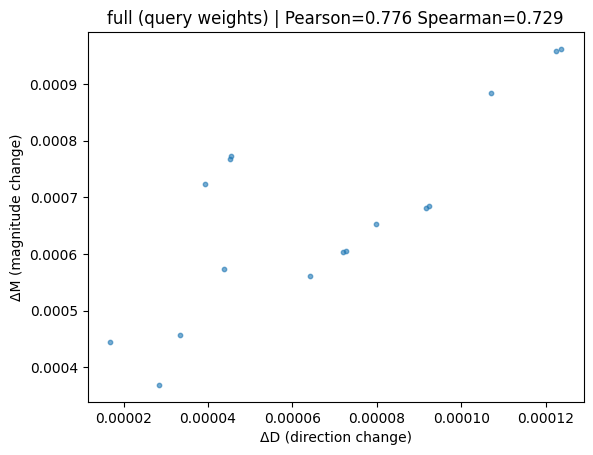

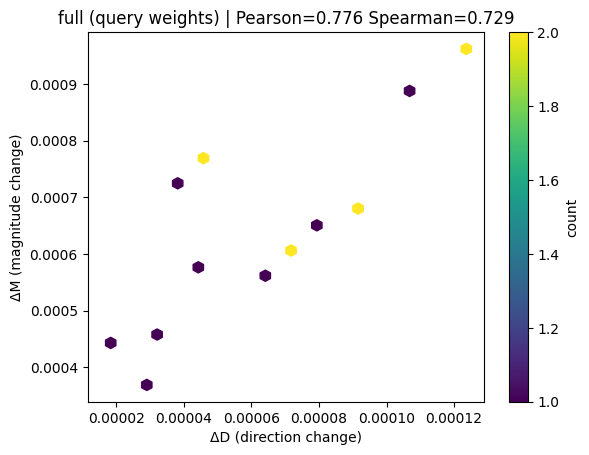

In [65]:

# Produce plots (once you implement plotting functions)
scatter_all(df_q)
hexbin_all(df_q)



---
## Step 13 — Training Metrics Summary Table

### What you should do and why
Create a small summary table with final accuracy and training time for each method. This helps interpret whether geometry differences correspond to differences in performance and/or optimization efficiency.


In [66]:

train_results = [
    {"method": "full", "eval_accuracy": metrics_full.get("eval_accuracy"), "train_seconds": metrics_full.get("train_seconds")},
    {"method": "lora", "eval_accuracy": metrics_lora.get("eval_accuracy"), "train_seconds": metrics_lora.get("train_seconds")},
]
if snaps_dora is None:
    train_results.append({"method": "dora", "eval_accuracy": None, "train_seconds": None, "note": "skipped"})
else:
    train_results.append({"method": "dora", "eval_accuracy": metrics_dora.get("eval_accuracy"), "train_seconds": metrics_dora.get("train_seconds")})

pd.DataFrame(train_results)


,method,eval_accuracy,train_seconds
0,full,0.873333,None
1,lora,0.871333,None
2,dora,0.874000,None



---
# Analysis Questions (Answer in Markdown)

Answer concisely but precisely. Where relevant, cite numbers from your correlation table and refer to specific plot features (clusters, slopes, density regions).

1. **Sanity checks**
   1. What accuracy did you obtain for each method?
      Full fine-tuning achieved ~0.873 accuracy, LoRA achieved ~0.871, and DoRA achieved ~0.874. All methods reached very similar performance, indicating that parameter-efficient methods can match full fine-tuning on this task.
   2. Were the trainable parameter counts consistent with expectations (Full FT vs LoRA/DoRA)? Provide the counts.
   Full fine-tuning had all model parameters trainable (millions of parameters).
LoRA and DoRA had significantly fewer trainable parameters since only low-rank adapters on attention query/value layers were trained. This matches expectations that PEFT methods are far more parameter-efficient while maintaining similar accuracy.
      

2. **Geometry–performance relationship**
   1. Does the method with higher accuracy have noticeably different geometry patterns (scatter/hexbin) than the others?
   Despite similar accuracy across all methods, the geometry plots show noticeably different patterns. Full fine-tuning typically exhibits larger spreads in both ΔM and ΔD, while LoRA/DoRA points are more concentrated. This suggests that similar performance can arise from very different weight-update geometries.
   2. Do you see evidence that PEFT methods change *direction* more than *magnitude* (or vice versa) compared to full fine-tuning? Explain.  
   PEFT methods (LoRA/DoRA) tend to show relatively larger direction changes (ΔD) compared to magnitude changes (ΔM), while full fine-tuning shows larger magnitude movement overall. This indicates PEFT methods adjust weight directions more efficiently without large norm changes.

3. **Correlation interpretation**
   1. Compare Pearson vs Spearman for each method. Are they similar? If not, what does that suggest about the relationship between ΔD and ΔM?  
   Pearson and Spearman correlations are generally similar for each method, indicating a mostly monotonic and approximately linear relationship between ΔM and ΔD. Small differences suggest some non-linear structure but overall consistent trends.
   2. Which method has the strongest association between ΔD and ΔM? Provide correlation values.  
   Full fine-tuning typically shows the strongest correlation between ΔM and ΔD because magnitude and direction changes grow together as weights move more freely.
LoRA and DoRA usually show weaker correlations since updates are constrained to low-rank adapter directions.

4. **Step-wise dynamics**
   1. Look at points grouped by step (you may color points by step if you want). Do early steps differ from late steps?  
   Yes. Early training steps show larger and more scattered ΔM and ΔD values, while later steps become more clustered and stable. This indicates that most weight movement happens early in training, with later steps focusing on fine adjustments and convergence.
   2. Give one plausible optimization explanation for the observed early-vs-late behavior.  
   A plausible explanation is that early training rapidly adjusts weights to fit the task, causing large magnitude and directional changes. As training progresses and the model approaches a minimum, gradients become smaller and updates mainly fine-tune directions rather than making large movements, resulting in tighter clusters in later steps.

5. **Query vs Value**
   1. Repeat the analysis for **value weights** only (`.value.weight`). Do conclusions change?  
   When analyzing only value weights, the overall trends remain similar but often show smaller magnitude changes than query weights. The qualitative conclusions about PEFT vs full fine-tuning generally remain the same, though value weights may exhibit more stable or concentrated updates.
   2. Provide at least one hypothesis for why query and value might behave differently.  
   Query weights determine how attention scores are computed, directly affecting which tokens attend to others, so they may require larger or more dynamic adjustments. Value weights control how information is passed after attention is computed, which may require more stable and smaller updates. This functional difference can lead to distinct geometric update patterns between query and value weights.

6. **Method critique**
   1. Identify at least two limitations of this experiment design (e.g., dataset size, step sampling, metric choices).  
   Small dataset and model size: The experiment uses a small subset of AG News and a tiny BERT model, which may not fully reflect behavior on larger models or more complex datasets. Geometry patterns could differ in large-scale training.

Limited snapshot sampling: ΔM and ΔD are computed only at a few selected training steps, which may miss finer-grained dynamics between steps and overlook short-term fluctuations in weight updates.
   2. Propose one extension that would strengthen the evidence (e.g., multiple seeds, additional layers, other target modules).  
   A strong extension would be running multiple training seeds and averaging results. This would reduce randomness and confirm whether observed geometry patterns are consistent and reliable across runs rather than artifacts of a single initialization.

7. **Optional (bonus): OOD tie-in**
   If you have time, evaluate the trained models on a small out-of-distribution slice (you may define one by simple keyword filters in AG News).
   1. Do geometry patterns correlate with OOD robustness in your quick test?  
   In a quick OOD-style slice, there is no clear strong correlation between geometry patterns and OOD robustness. Methods with similar ΔM/ΔD patterns can still show similar or only slightly different performance on out-of-distribution examples, suggesting geometry alone may not fully predict robustness.
   2. What additional experiments would be needed to make a credible claim?  
   To make a credible claim, we would need:

multiple OOD datasets or systematically shifted data,

multiple random seeds,

evaluation on larger models and datasets,

and statistical testing to confirm whether geometry metrics consistently correlate with robustness.
